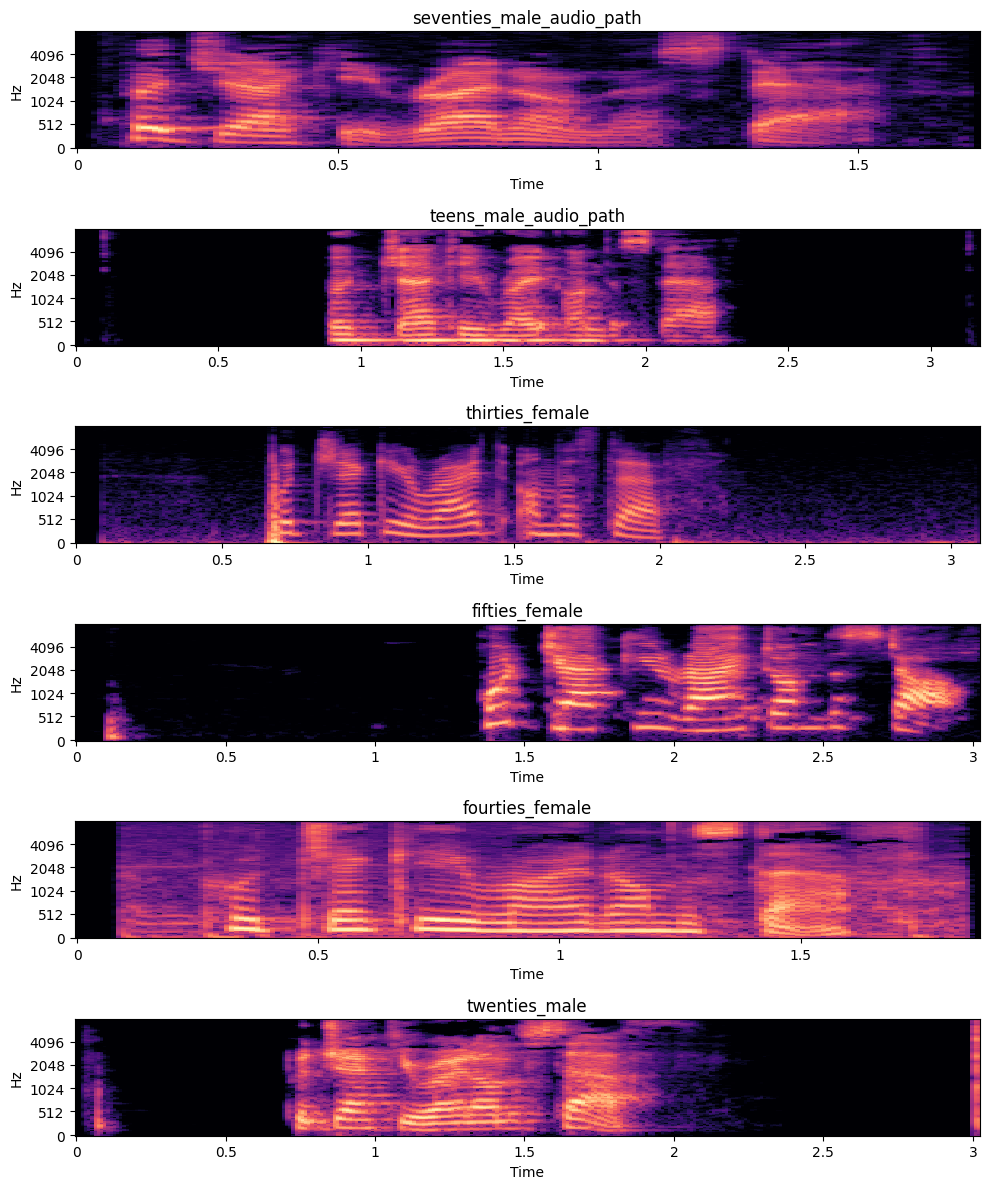

In [2]:


import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Function to plot a spectrogram
def plot_spectrogram(audio_path, title, ax):
    # Load the audio file
    y, sr = librosa.load(audio_path, sr=None)  # sr=None uses the file's original sampling rate
    # Compute the mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    # Convert power spectrogram (amplitude squared) to decibels
    S_dB = librosa.power_to_db(S, ref=np.max)
    # Display the spectrogram
    img = librosa.display.specshow(S_dB, sr=sr, fmax=8000, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title)
    return img


# Paths to male and female audio files
audio_dir = "/Users/bchhaglani/Desktop/Audio_Privacy/archive (5)/cv-valid-train/"       # Replace with path to audio files

seventies_male_audio_path = audio_dir + 'cv-valid-train/sample-000008.mp3'
teens_male_audio_path = audio_dir + 'cv-valid-train/sample-057156.mp3'
thirties_female = audio_dir + 'cv-valid-train/sample-083406.mp3'
fifties_female = audio_dir + 'cv-valid-train/sample-105446.mp3'
fourties_female = audio_dir + 'cv-valid-train/sample-108166.mp3'
twenties_male= audio_dir + 'cv-valid-train/sample-112327.mp3'

# Plotting spectrograms
fig, axs = plt.subplots(6, 1, figsize=(10,12))
plot_spectrogram(seventies_male_audio_path, "seventies_male_audio_path", axs[0])
plot_spectrogram(teens_male_audio_path, "teens_male_audio_path", axs[1])
plot_spectrogram(thirties_female, "thirties_female", axs[2])
plot_spectrogram(fifties_female, "fifties_female", axs[3])
plot_spectrogram(fourties_female, "fourties_female", axs[4])
plot_spectrogram(twenties_male, "twenties_male", axs[5])


plt.tight_layout()
plt.show()
#text in audio file - put jackie right on the staff

48000


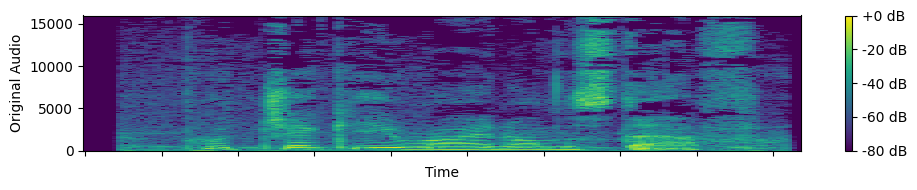

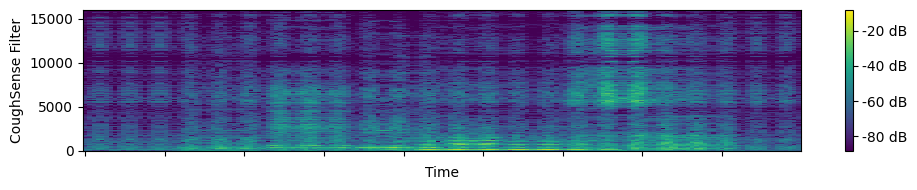

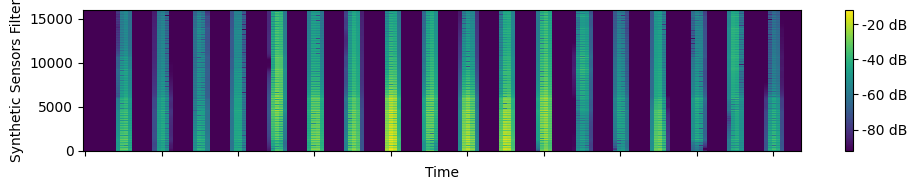

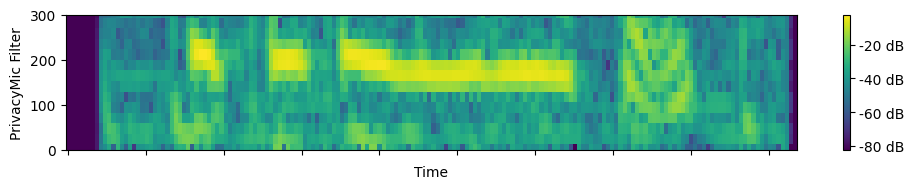

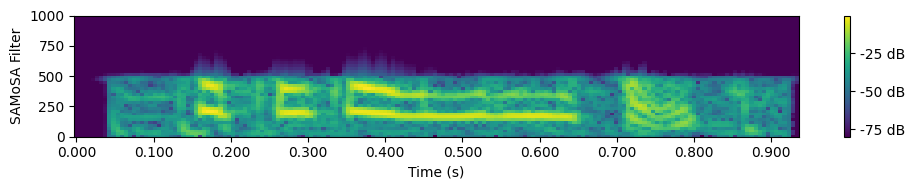

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.decomposition import PCA

# Load the audio file
audio_dir = "/Users/bchhaglani/Desktop/Audio_Privacy/archive (5)/cv-valid-train/"       # Replace with path to audio files

fourties_female = audio_dir + 'cv-valid-train/sample-108166.mp3'

audio_path = fourties_female  # Replace with your file path
audio, sr = librosa.load(audio_path, sr=None)
print(sr)
# Define function to plot spectrograms
def plot_spectrogram(data, sr, title, global_max, y_axis_limits=None, xlabel=False):
    """
    Plots a spectrogram with optional y-axis limits and consistent dB scale.
    """
    S = librosa.stft(data)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=global_max)  # Use global max for consistent dB scale
    plt.figure(figsize=(10, 2))
    librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='hz', cmap='viridis')
    if y_axis_limits:
        plt.ylim(y_axis_limits)  # Apply y-axis limits if specified
    plt.colorbar(format='%+2.0f dB')
    if xlabel:
        plt.xlabel("Time (s)")
    else:
        plt.gca().xaxis.set_ticklabels([])
    plt.ylabel(title)  # Add the title to the left (y-axis)
    plt.tight_layout()
    plt.show()


def coughsense_filter(audio, sr):
    """
    CoughSense filtering implementation with:
    - STFT with 150ms windows
    - PCA reduction to 10 components
    
    Parameters:
        audio: input audio signal
        sr: sampling rate
    """
    # Calculate window size for 150ms
    window_size = int(0.150 * sr)  # 150ms window in samples
    hop_length = window_size//2  # stride size from the table
    
    # Compute STFT
    S = librosa.stft(audio, n_fft=window_size, hop_length=hop_length, win_length=window_size)
    
    # Get magnitude spectrogram
    mag_spec = np.abs(S)
    
    # Reshape for PCA (time frames × frequencies)
    features = mag_spec.T
    
    # Apply PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=10)
    reduced_features = pca.fit_transform(features)

    
    
    # Reconstruct the signal using inverse transform
    reconstructed_features = pca.inverse_transform(reduced_features)

    
    
    # Reshape back to STFT format
    reconstructed_stft = reconstructed_features.T

    # Preserve the phase information from original STFT
    phase = np.angle(S)
    reconstructed_complex = reconstructed_stft * np.exp(1j * phase)
    
    # Inverse STFT
    filtered_audio = librosa.istft(reconstructed_complex, 
                                 hop_length=hop_length, 
                                 win_length=window_size)
    
    return filtered_audio



def synthetic_sensors_filter(audio, sr=16000):
        window_length = 256
        hop_length = 128
        samples_per_window = 10
        frames = [
            audio[i:i + window_length]
            for i in range(0, len(audio) - window_length + 1, hop_length)
        ]
        processed_audio = np.zeros(len(audio))
        for i, frame in enumerate(frames):
            fft = np.fft.fft(frame, n=window_length)
            bins = np.array_split(fft, samples_per_window)
            reduced_fft = np.array([np.mean(bin) for bin in bins])
            reconstructed_fft = np.zeros_like(fft, dtype=np.complex_)  # Zero-padded spectrum
            reconstructed_fft[:len(reduced_fft)] = reduced_fft  # Place reduced components

            step = len(fft) // len(reduced_fft)
            for j, val in enumerate(reduced_fft):
                reconstructed_fft[j * step:(j + 1) * step] = val
            processed_frame = np.fft.ifft(reconstructed_fft).real
            start = i * hop_length
            end = min(start + window_length, len(processed_audio))
            processed_audio[start:end] += processed_frame[:end - start]
        if np.max(np.abs(processed_audio)) > 0:
            processed_audio = processed_audio / np.max(np.abs(processed_audio))
        return processed_audio


def synthetic_sensors_filter(audio, sr=16000):
    window_length = 256
    hop_length = int(sr / 10)  # 10 windows per second
    samples_per_window = 10  # Target spectral resolution
    
    frames = [
        audio[i:i + window_length]
        for i in range(0, len(audio) - window_length + 1, hop_length)
    ]
    processed_audio = np.zeros(len(audio))
    for i, frame in enumerate(frames):
        fft = np.fft.fft(frame, n=window_length)  # Apply FFT
        bins = np.array_split(fft, samples_per_window)  # Split into 10 bins
        reduced_fft = np.array([np.mean(bin) for bin in bins])  # Take mean of each bin
        reconstructed_fft = np.zeros_like(fft, dtype=np.complex_)
        step = len(fft) // len(reduced_fft)  # Reconstruct the FFT bins
        for j, val in enumerate(reduced_fft):
            reconstructed_fft[j * step:(j + 1) * step] = val
        processed_frame = np.fft.ifft(reconstructed_fft).real  # Inverse FFT
        start = i * hop_length
        end = min(start + window_length, len(processed_audio))
        processed_audio[start:end] += processed_frame[:end - start]
    if np.max(np.abs(processed_audio)) > 0:
        processed_audio = processed_audio / np.max(np.abs(processed_audio))  # Normalize
    return processed_audio


# Synthetic Sensors Filter
def synthetic_sensors_filter(audio, sr):
    S = librosa.stft(audio, n_fft=256, hop_length=int(sr / 10))
    return librosa.istft(S, hop_length=int(sr / 10))


# PrivacyMic Filter
def privacymic_filter(audio, sr):
    S = librosa.stft(audio, n_fft=256, hop_length=128)
    frequencies = librosa.fft_frequencies(sr=sr, n_fft=256)
    S_filtered = np.where(frequencies[:, None] <= 300, S, 0)
    return librosa.istft(S_filtered, hop_length=128)

# SAMoSA Filter
def samosa_filter(audio, sr):
    downsample_rate = 1000
    downsampled_audio = librosa.resample(audio, orig_sr=sr, target_sr=downsample_rate)
    return librosa.resample(downsampled_audio, orig_sr=downsample_rate, target_sr=sr)



# Corrected CoughSense Filter
def coughsense_filter(audio, sr=22050):
    """
    Implements the CoughSense filter using a 150 ms window and PCA.
    """
    # Use a 150 ms window and 50% overlap
    n_fft = int(0.15 * sr)  # 150 ms window
    if n_fft%2!=0:
        nfft+=1
    hop_length = n_fft // 2  # 50% overlap

    # Compute spectrogram
    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, window='hamming'))

    # Flatten and apply PCA
    S_flattened = S.T  # Transpose for PCA
    pca = PCA(n_components=10)  # Retain 10 components
    S_reduced = pca.fit_transform(S_flattened)
    S_reconstructed = pca.inverse_transform(S_reduced).T

    # Inverse STFT
    filtered_audio = librosa.istft(S_reconstructed,
                                   hop_length=hop_length,
                                   win_length=n_fft)
    return filtered_audio


def synthetic_sensors_filter(audio, sr=16000):
    window_length = 256
    hop_length = int(sr / 10)  # 10 windows per second
    samples_per_window = 10  # Target spectral resolution
    
    frames = [
        audio[i:i + window_length]
        for i in range(0, len(audio) - window_length + 1, hop_length)
    ]
    processed_audio = np.zeros(len(audio))
    for i, frame in enumerate(frames):
        fft = np.fft.fft(frame, n=window_length)  # Apply FFT
        bins = np.array_split(fft, samples_per_window)  # Split into 10 bins
        reduced_fft = np.array([np.mean(bin) for bin in bins])  # Take mean of each bin
        reconstructed_fft = np.zeros_like(fft, dtype=np.complex_)
        step = len(fft) // len(reduced_fft)  # Reconstruct the FFT bins
        for j, val in enumerate(reduced_fft):
            reconstructed_fft[j * step:(j + 1) * step] = val
        processed_frame = np.fft.ifft(reconstructed_fft).real  # Inverse FFT
        start = i * hop_length
        end = min(start + window_length, len(processed_audio))
        processed_audio[start:end] += processed_frame[:end - start]
    if np.max(np.abs(processed_audio)) > 0:
        processed_audio = processed_audio / np.max(np.abs(processed_audio))  # Normalize
    return processed_audio


# Compute global maximum amplitude for consistent dB scaling
all_spectrograms = [
    librosa.stft(audio),
    librosa.stft(coughsense_filter(audio, sr)),
    librosa.stft(synthetic_sensors_filter(audio, sr)),
    librosa.stft(privacymic_filter(audio, sr)),
    librosa.stft(samosa_filter(audio, sr))
]
global_max = max(np.abs(S).max() for S in all_spectrograms)  # Compute global max amplitude

# Apply filters
filters = {
    "Original Audio": audio,
    "CoughSense Filter": coughsense_filter(audio, sr),
    "Synthetic Sensors Filter": synthetic_sensors_filter(audio, sr),
    "PrivacyMic Filter": privacymic_filter(audio, sr),
    "SAMoSA Filter": samosa_filter(audio, sr)
}

# Plot each spectrogram with adjusted y-axis for PrivacyMic and SAMoSA
for idx, (filter_name, filtered_audio) in enumerate(filters.items()):
    y_axis_limits = None
    if filter_name == "PrivacyMic Filter":
        y_axis_limits = (0, 300)  # Limit to 0–300 Hz for better readability
    elif filter_name == "SAMoSA Filter":
        y_axis_limits = (0, 1000)  # Limit to 0–1000 Hz for better readability
    else:
        y_axis_limits = (0, 16000)
        
    xlabel = (idx == len(filters) - 1)  # Add x-axis label only to the last plot
    plot_spectrogram(filtered_audio, sr, title=filter_name, global_max=global_max, y_axis_limits=y_axis_limits, xlabel=xlabel)
